# CPS Employment Data

The [Current Population Survey (CPS)](https://www.census.gov/programs-surveys/cps.html) is the primary source of U.S. labor force statistics, conducted monthly by the Census Bureau and Bureau of Labor Statistics.

We extracted individual-level microdata from [IPUMS CPS](https://cps.ipums.org/cps/) with the following variables:

| Variable | Description | Values |
|----------|-------------|--------|
| `YEAR` | Survey year | 2024 |
| `MONTH` | Survey month | 1–12 |
| `METRO` | Metropolitan area status | 0=Not identified, 1=Non-metro, 2=Central city, 3=Not central city, 4=Central city status unknown, 9=Missing |
| `FAMINC` | Family income of householder | Categorical codes (e.g., 100=Under $5k, 600=$20–25k, 710=$25–30k, 840=$75k+); 995–999=Missing/Refused |
| `AGE` | Age | 0–99 |
| `SEX` | Sex | 1=Male, 2=Female, 9=NIU |
| `MARST` | Marital status | 1=Married spouse present, 2=Married spouse absent, 3=Separated, 4=Divorced, 5=Widowed, 6=Never married, 9=NIU |
| `EMPSTAT` | Employment status | 0=NIU, 1=Armed Forces, 10=At work, 12=Has job not at work, 20=Unemployed, 21=Unemployed experienced, 22=Unemployed new, 30–36=Not in labor force |
| `OCC` | Occupation | 4-digit Census occupation codes (e.g., 4150=Secretaries, 7260=Construction laborers) |
| `IND` | Industry | 4-digit Census industry codes (e.g., 8660=Restaurants, 6170=Construction) |
| `CLASSWKR` | Class of worker | 13=Self-employed not inc., 14=Self-employed inc., 22=Private for-profit, 23=Private nonprofit, 25=Federal govt, 27=State govt, 28=Local govt, 29=Unpaid family |
| `EDUC` | Educational attainment | 1=NIU, 73=HS diploma, 81=Some college, 91–92=Associate's, 111=Bachelor's, 123=Master's, 124=Professional, 125=Doctorate, 999=Missing |

The data is in fixed-width format (`cps_00001.dat`), so we use the column positions from the IPUMS codebook to read it.

## Read the fixed-width data file

In [98]:
import pandas as pd
import numpy as np

# Column positions from the IPUMS SAS codebook (1-indexed, inclusive)
# Convert to 0-indexed half-open intervals for pandas
colspecs = [
    (0, 4),      # YEAR        1-4
    (4, 9),      # SERIAL      5-9
    (9, 11),     # MONTH       10-11
    (11, 21),    # HWTFINL     12-21  (4 implied decimals)
    (21, 35),    # CPSID       22-35
    (35, 36),    # ASECFLAG    36-36
    (36, 47),    # ASECWTH     37-47  (4 implied decimals)
    (47, 48),    # METRO       48-48
    (48, 51),    # FAMINC      49-51
    (51, 53),    # PERNUM      52-53
    (53, 67),    # WTFINL      54-67  (4 implied decimals)
    (67, 81),    # CPSIDP      68-81
    (81, 96),    # CPSIDV      82-96
    (96, 107),   # ASECWT      97-107 (4 implied decimals)
    (107, 109),  # AGE         108-109
    (109, 110),  # SEX         110-110
    (110, 111),  # MARST       111-111
    (111, 113),  # EMPSTAT     112-113
    (113, 117),  # OCC         114-117
    (117, 121),  # IND         118-121
    (121, 123),  # CLASSWKR    122-123
    (123, 126),  # EDUC        124-126
]

col_names = ['YEAR', 'SERIAL', 'MONTH', 'HWTFINL', 'CPSID', 'ASECFLAG',
             'ASECWTH', 'METRO', 'FAMINC', 'PERNUM', 'WTFINL', 'CPSIDP',
             'CPSIDV', 'ASECWT', 'AGE', 'SEX', 'MARST', 'EMPSTAT',
             'OCC', 'IND', 'CLASSWKR', 'EDUC']

cps = pd.read_fwf('cps_00001.dat', colspecs=colspecs, names=col_names, header=None)

# Adjust implied decimal columns (4 implied decimal places)
for col in ['HWTFINL', 'ASECWTH', 'WTFINL', 'ASECWT']:
    cps[col] = cps[col] / 10000

print(f"Dataset shape: {cps.shape}")
cps.head()

Dataset shape: (2371312, 22)


,YEAR,SERIAL,MONTH,HWTFINL,CPSID,ASECFLAG,ASECWTH,METRO,FAMINC,PERNUM,...,CPSIDV,ASECWT,AGE,SEX,MARST,EMPSTAT,OCC,IND,CLASSWKR,EDUC
0,2024,1,1,2555.8908,20240100000100,NaN,NaN,1,710,1,...,202401000001011,NaN,58,2,4,36,0,0,0,73
1,2024,4,1,2481.6628,20240100000400,NaN,NaN,1,600,1,...,202401000004011,NaN,64,2,4,10,4150,8660,22,111
2,2024,5,1,3032.1001,20240100000500,NaN,NaN,1,470,1,...,202401000005011,NaN,44,1,4,10,7260,6170,22,50
3,2024,5,1,3032.1001,20240100000500,NaN,NaN,1,470,2,...,202401000005021,NaN,80,2,5,36,0,0,0,30
4,2024,5,1,3032.1001,20240100000500,NaN,NaN,1,470,3,...,202401000005031,NaN,35,2,6,21,3840,9490,28,73


## Explore the raw data

In [ ]:
cps.dtypes

In [ ]:
# Employment status distribution
empstat_labels = {
    0: 'NIU',
    1: 'Armed Forces',
    10: 'At work',
    12: 'Has job, not at work last week',
    20: 'Unemployed',
    21: 'Unemployed, experienced worker',
    22: 'Unemployed, new worker',
    30: 'Not in labor force',
    31: 'NILF, housework',
    32: 'NILF, unable to work',
    33: 'NILF, school',
    34: 'NILF, other',
    35: 'NILF, unpaid, lt 15 hours',
    36: 'NILF, retired'
}

out = cps['EMPSTAT'].value_counts().to_frame('count')
out['label'] = out.index.map(empstat_labels)
out['percent'] = (out['count'] / out['count'].sum() * 100).round(1)
print(out)

In [ ]:
# Education distribution
educ_labels = {
    0: 'NIU or no schooling', 1: 'NIU or blank', 2: 'None or preschool',
    10: 'Grades 1-4', 20: 'Grades 5-6', 30: 'Grades 7-8',
    40: 'Grade 9', 50: 'Grade 10', 60: 'Grade 11', 70: 'Grade 12',
    71: '12th grade, no diploma', 72: '12th grade, diploma unclear',
    73: 'High school diploma or equivalent',
    80: '1 year of college', 81: 'Some college but no degree',
    90: '2 years of college', 91: "Associate's, vocational",
    92: "Associate's, academic",
    100: '3 years of college', 110: '4 years of college',
    111: "Bachelor's degree",
    120: '5+ years of college', 121: '5 years of college',
    122: '6+ years of college', 123: "Master's degree",
    124: 'Professional school degree', 125: 'Doctorate degree',
    999: 'Missing/Unknown'
}

out = cps['EDUC'].value_counts().sort_index().to_frame('count')
out['label'] = out.index.map(educ_labels)
out['percent'] = (out['count'] / out['count'].sum() * 100).round(1)
print(out.to_string())

## Clean the data

### Step 1: Remove NIU (Not In Universe) and missing/invalid codes

NIU means the question did not apply to that person (e.g., children under 15 are not asked about employment). We remove rows with NIU or missing/refused codes so every observation has valid data.

In [ ]:
# NIU and missing codes for each variable (from the IPUMS codebook)
niu_codes = {
    'EMPSTAT':  [0],                    # 0 = NIU
    'EDUC':     [0, 1, 999],            # 0 = NIU/no schooling, 1 = NIU/blank, 999 = Missing
    'CLASSWKR': [0, 99],               # 0 = NIU, 99 = Missing/Unknown
    'SEX':      [9],                    # 9 = NIU
    'MARST':    [9],                    # 9 = NIU
    'METRO':    [0, 9],                 # 0 = Not identified, 9 = Missing
    'FAMINC':   [995, 996, 997, 999],   # Missing / Refused / Don't know / Blank
}

print(f"Before removing NIU/missing: {len(cps):,} rows")

cps_clean = cps.copy()
for col, codes in niu_codes.items():
    before = len(cps_clean)
    cps_clean = cps_clean[~cps_clean[col].isin(codes)]
    dropped = before - len(cps_clean)
    if dropped > 0:
        print(f"  Dropped {dropped:>7,} rows with NIU/missing in {col}")

print(f"After removing NIU/missing:  {len(cps_clean):,} rows")

### Step 2: Filter to recent university graduates (ages 22-30) who are employed

We focus on young adults (22-30) with at least a bachelor's degree who are currently employed (EMPSTAT 10 or 12). Since we are predicting class of worker, we need people who have a job. We deduplicate on CPSIDP since CPS uses a rotating panel design.

In [ ]:
# Filter to recent university graduates (22-30) who are employed
# EDUC >= 111 means bachelor's degree or higher
# EMPSTAT 10 or 12 means currently employed
cps_lf = cps_clean[
    (cps_clean['AGE'] >= 22) & (cps_clean['AGE'] <= 30) &
    (cps_clean['EDUC'] >= 111) &
    (cps_clean['EMPSTAT'].isin([10, 12]))
].copy()

# Deduplicate: CPS uses a rotating panel, so the same person can appear
# in multiple months. Keep only the first observation per person.
print(f"Before deduplication: {len(cps_lf):,} rows")
cps_lf = cps_lf.drop_duplicates(subset='CPSIDP', keep='first')
print(f"After deduplication:  {len(cps_lf):,} rows")

print(f"\nClass of worker distribution:")
print(cps_lf['CLASSWKR'].value_counts().sort_index())

### Step 3: Recode predictors and target

In [ ]:
# Recode education into degree categories (all have bachelor's or higher)
def recode_educ(x):
    if x == 111:           # bachelor's degree
        return 1
    elif x == 123:         # master's degree
        return 2
    elif x in [124, 125]:  # professional or doctorate
        return 3
    else:
        return np.nan

cps_lf['educ_cat'] = cps_lf['EDUC'].apply(recode_educ)

educ_cat_labels = {1: "Bachelor's", 2: "Master's", 3: 'Professional/Doctorate'}

out = cps_lf['educ_cat'].value_counts().sort_index().to_frame('count')
out['label'] = out.index.map(educ_cat_labels)
out['percent'] = (out['count'] / out['count'].sum() * 100).round(1)
print(out)

In [80]:
# Recode family income into Low / Middle / High
# FAMINC codes: <=730 = under $40k, 740-830 = $40k-$75k, 840+ = $75k+
def recode_faminc(x):
    if x <= 730:      # under $40,000
        return 1      # Low
    elif x <= 830:    # $40,000 - $74,999
        return 2      # Middle
    else:             # $75,000+
        return 3      # High

cps_lf['faminc_cat'] = cps_lf['FAMINC'].apply(recode_faminc)

faminc_labels = {1: 'Low (<$40k)', 2: 'Middle ($40k-$75k)', 3: 'High ($75k+)'}

out = cps_lf['faminc_cat'].value_counts().sort_index().to_frame('count')
out['label'] = out.index.map(faminc_labels)
out['percent'] = (out['count'] / out['count'].sum() * 100).round(1)
print(out)

            count               label  percent
faminc_cat                                    
1            2849         Low (<$40k)     11.2
2            5147  Middle ($40k-$75k)     20.3
3           17355        High ($75k+)     68.5


In [81]:
# Recode metro: 1 = non-metro -> 0; 2,3,4 = metro -> 1
cps_lf['metro_binary'] = cps_lf['METRO'].map({1: 0, 2: 1, 3: 1, 4: 1})

# Recode sex: 1=Male -> 0, 2=Female -> 1
cps_lf['female'] = (cps_lf['SEX'] == 2).astype(int)

# Recode marital status: 1,2 = married; 3-7 = not married
cps_lf['married'] = (cps_lf['MARST'].isin([1, 2])).astype(int)

print(f"Female: {cps_lf['female'].mean():.3f}")
print(f"Married: {cps_lf['married'].mean():.3f}")
print(f"Metro: {cps_lf['metro_binary'].mean():.3f}")

Female: 0.557
Married: 0.264
Metro: 0.901


In [84]:
# Recode class of worker into 4 categories (this is our target variable)
def recode_classwkr(x):
    if x in [13, 14]:       # self-employed (incorporated or not)
        return 'Self-employed'
    elif x == 22:           # private, for profit
        return 'Private for-profit'
    elif x == 23:           # private, nonprofit
        return 'Private nonprofit'
    elif x in [25, 27, 28]: # federal, state, or local government
        return 'Government'
    else:                   # 21 = wage/salary private, 29 = unpaid family, etc.
        return np.nan

cps_lf['classwkr_cat'] = cps_lf['CLASSWKR'].apply(recode_classwkr)

out = cps_lf['classwkr_cat'].value_counts().to_frame('count')
out['percent'] = (out['count'] / out['count'].sum() * 100).round(1)
print(out)

                    count  percent
classwkr_cat                      
Private for-profit  16427     67.4
Government           4268     17.5
Private nonprofit    2755     11.3
Self-employed         932      3.8


### Summaries: Industry and Occupation

In [85]:
# Industry - top 15 most common
out = cps_lf['IND'].value_counts().head(15).to_frame('count')
out['percent'] = (out['count'] / len(cps_lf) * 100).round(1)
print("IND (Industry) - Top 15")
print(out.to_string())
print(f"\nTotal unique industries: {cps_lf['IND'].nunique()}")

IND (Industry) - Top 15
      count  percent
IND                 
7860   1966      7.8
8191   1859      7.3
7870   1464      5.8
7380   1165      4.6
8680    920      3.6
770     792      3.1
8090    640      2.5
7390    637      2.5
7290    600      2.4
7270    442      1.7
6970    438      1.7
7280    422      1.7
9470    403      1.6
8370    393      1.6
8590    358      1.4

Total unique industries: 291


In [86]:
# Occupation - top 15 most common
out = cps_lf['OCC'].value_counts().head(15).to_frame('count')
out['percent'] = (out['count'] / len(cps_lf) * 100).round(1)
print("OCC (Occupation) - Top 15")
print(out.to_string())
print(f"\nTotal unique occupations: {cps_lf['OCC'].nunique()}")

OCC (Occupation) - Top 15
      count  percent
OCC                 
3255   1152      4.5
2310   1087      4.3
1021    951      3.8
440     717      2.8
800     604      2.4
2545    543      2.1
4760    370      1.5
710     368      1.5
5240    358      1.4
2320    290      1.1
4110    287      1.1
735     284      1.1
630     269      1.1
1530    263      1.0
4700    256      1.0

Total unique occupations: 481


### Step 4: Select features and check for remaining missing values

In [87]:
feature_cols = ['AGE', 'female', 'married', 'educ_cat', 'faminc_cat', 'metro_binary',
                'OCC', 'IND']
target_col = 'classwkr_cat'

cps_model = cps_lf[feature_cols + [target_col]].copy()

# Check for any remaining missing values
print("Missing values per column:")
print(cps_model.isnull().sum())
print(f"\nRows before dropping NaN: {len(cps_model):,}")

cps_model = cps_model.dropna()
print(f"Rows after dropping NaN:  {len(cps_model):,}")
print(f"\nClass of worker distribution:")
print(cps_model[target_col].value_counts())
cps_model.head(10)

Missing values per column:
AGE               0
female            0
married           0
educ_cat          0
faminc_cat        0
metro_binary      0
OCC               0
IND               0
classwkr_cat    969
dtype: int64

Rows before dropping NaN: 25,351
Rows after dropping NaN:  24,382

Class of worker distribution:
classwkr_cat
Private for-profit    16427
Government             4268
Private nonprofit      2755
Self-employed           932
Name: count, dtype: int64


,AGE,female,married,educ_cat,faminc_cat,metro_binary,OCC,IND,classwkr_cat
83,25,0,0,2,3,1,800,7280,Private for-profit
84,27,1,0,2,3,1,5940,8191,Private for-profit
86,25,1,0,1,2,1,3255,8191,Private for-profit
178,25,1,0,2,3,1,230,8390,Private nonprofit
400,23,1,0,1,3,1,2310,7860,Government
429,25,0,0,1,3,1,9620,5593,Private for-profit
430,22,1,0,1,3,1,5240,5391,Private for-profit
433,25,1,0,1,3,1,800,570,Private for-profit
464,24,1,0,1,3,1,3255,8090,Private nonprofit
490,26,1,0,1,2,1,4710,6991,Private for-profit


## Class of worker by demographic groups

In [88]:
# Class of worker by education
ct = pd.crosstab(cps_model['educ_cat'].map(educ_cat_labels),
                 cps_model[target_col], normalize='index').round(3)
print("Class of worker by education level:")
print(ct)

Class of worker by education level:
classwkr_cat            Government  Private for-profit  Private nonprofit  \
educ_cat                                                                    
Bachelor's                   0.160               0.698              0.102   
Master's                     0.239               0.588              0.142   
Professional/Doctorate       0.166               0.613              0.190   

classwkr_cat            Self-employed  
educ_cat                               
Bachelor's                      0.040  
Master's                        0.031  
Professional/Doctorate          0.032  


In [89]:
# Class of worker by family income
ct = pd.crosstab(cps_model['faminc_cat'].map(faminc_labels),
                 cps_model[target_col], normalize='index').round(3)
print("Class of worker by family income:")
print(ct)

Class of worker by family income:
classwkr_cat        Government  Private for-profit  Private nonprofit  \
faminc_cat                                                              
High ($75k+)             0.160               0.700              0.105   
Low (<$40k)              0.197               0.625              0.123   
Middle ($40k-$75k)       0.213               0.612              0.134   

classwkr_cat        Self-employed  
faminc_cat                         
High ($75k+)                0.035  
Low (<$40k)                 0.055  
Middle ($40k-$75k)          0.041  


## Save cleaned data

In [ ]:
# Save cleaned data for use in other notebooks
cps_model.to_csv('cps_employment_clean.csv', index=False)
print(f"Saved {len(cps_model):,} rows to cps_employment_clean.csv")

## Random Forest Model

We predict **class of worker** (Private for-profit, Private nonprofit, Government, Self-employed) from demographic and job characteristics. This is a multi-class classification problem.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [90]:
# Train/test split
X = cps_model[feature_cols]
y = cps_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set:     {len(X_test):,} rows")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set: 17,067 rows
Test set:     7,315 rows

Training class distribution:
classwkr_cat
Private for-profit    11499
Government             2988
Private nonprofit      1928
Self-employed           652
Name: count, dtype: int64

Test class distribution:
classwkr_cat
Private for-profit    4928
Government            1280
Private nonprofit      827
Self-employed          280
Name: count, dtype: int64


### Single Decision Tree (baseline)

In [91]:
# Single tree with max_depth=5
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

print(f"Decision Tree (max_depth=5)")
print(f"  Training accuracy: {accuracy_score(y_train, dt.predict(X_train)):.3f}")
print(f"  Test accuracy:     {accuracy_score(y_test, dt.predict(X_test)):.3f}")

Decision Tree (max_depth=5)
  Training accuracy: 0.813
  Test accuracy:     0.807


### Random Forest

In [92]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    random_state=42
)
rf.fit(X_train, y_train)

print(f"Random Forest (200 trees)")
print(f"  Training accuracy: {accuracy_score(y_train, rf.predict(X_train)):.3f}")
print(f"  Test accuracy:     {accuracy_score(y_test, rf.predict(X_test)):.3f}")

Random Forest (200 trees)
  Training accuracy: 0.958
  Test accuracy:     0.779


In [93]:
# Classification report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf.predict(X_test), digits=3))

Random Forest Classification Report:

                    precision    recall  f1-score   support

        Government      0.756     0.715     0.735      1280
Private for-profit      0.826     0.907     0.865      4928
 Private nonprofit      0.482     0.337     0.397       827
     Self-employed      0.294     0.114     0.165       280

          accuracy                          0.779      7315
         macro avg      0.589     0.518     0.540      7315
      weighted avg      0.754     0.779     0.762      7315



In [94]:
# Confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, rf.predict(X_test), labels=labels)
print("Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=[f'Actual: {l}' for l in labels],
                   columns=[f'Pred: {l}' for l in labels]))

Confusion Matrix:
                            Pred: Government  Pred: Private for-profit  \
Actual: Government                       915                       283   
Actual: Private for-profit               174                      4472   
Actual: Private nonprofit                119                       421   
Actual: Self-employed                      3                       240   

                            Pred: Private nonprofit  Pred: Self-employed  
Actual: Government                               78                    4  
Actual: Private for-profit                      217                   65  
Actual: Private nonprofit                       279                    8  
Actual: Self-employed                             5                   32  


### Variable Importance

In [95]:
# Variable importance (mean decrease in Gini)
importances = rf.feature_importances_
importance_df = (pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
                 .sort_values('Importance', ascending=False))

print(importance_df.to_string(index=False))

     Feature  Importance
         IND    0.499001
         OCC    0.298579
         AGE    0.113063
  faminc_cat    0.028502
    educ_cat    0.020958
     married    0.014777
      female    0.014254
metro_binary    0.010865


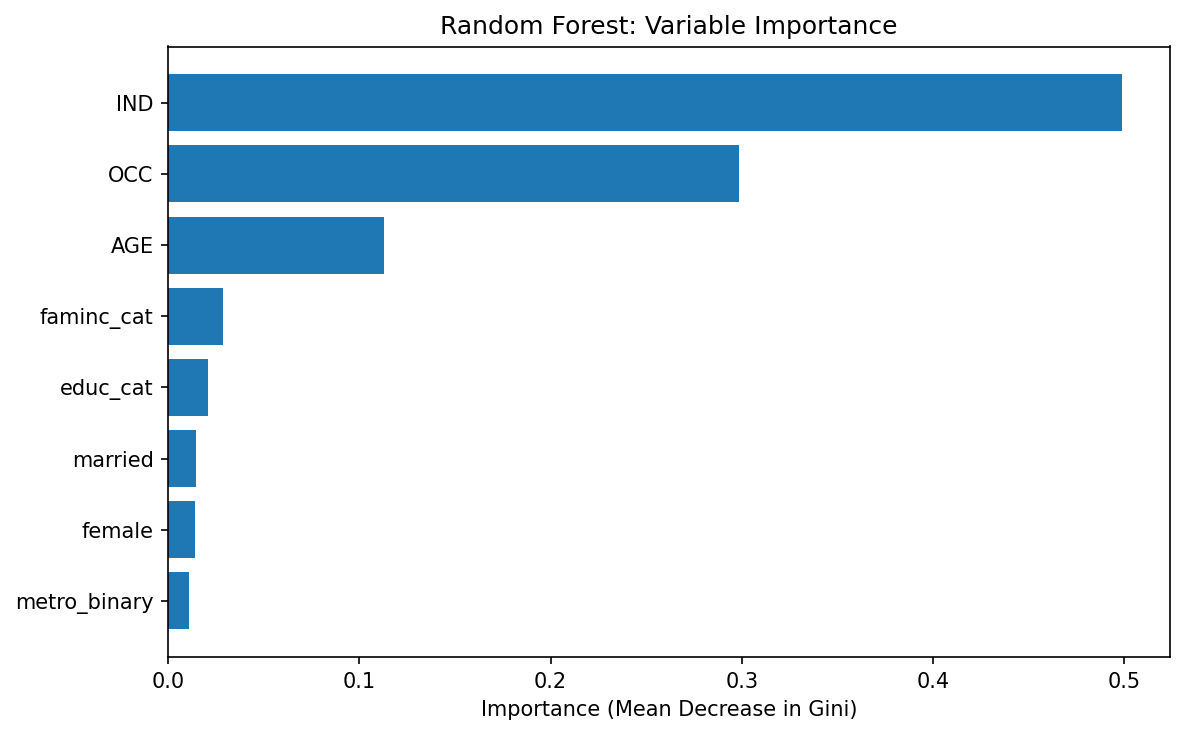

In [96]:
plt.figure(figsize=(8, 5), dpi=150)
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance (Mean Decrease in Gini)')
plt.title('Random Forest: Variable Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Effect of Number of Trees

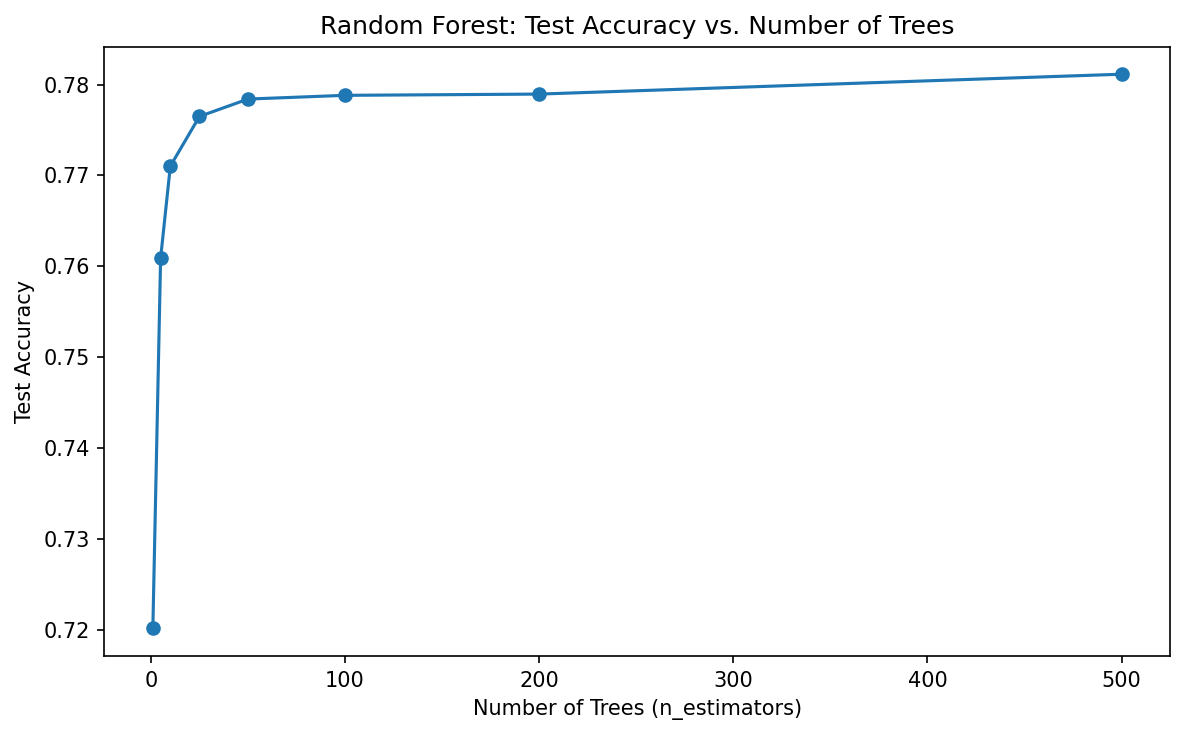

In [97]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 500]
rf_test_acc = []

for n_trees in n_trees_list:
    rf_temp = RandomForestClassifier(n_estimators=n_trees, max_features='sqrt', random_state=42)
    rf_temp.fit(X_train, y_train)
    rf_test_acc.append(accuracy_score(y_test, rf_temp.predict(X_test)))

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(n_trees_list, rf_test_acc, 'o-')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: Test Accuracy vs. Number of Trees')
plt.tight_layout()
plt.show()